# Fraud Detection Modeling

Modeller ROC-AUC, precision, recall ve F1-score metrikleri kullanılarak değerlendirilmiştir.

## 1. Giriş (Introduction)

Bu kapsamda Logistic Regression ve XGBoost algoritmaları kullanılarak fraud tespiti modelleri geliştirilmiştir. Veri setindeki sınıf dengesizliği problemi dikkate alınarak class_weight ve scale_pos_weight parametreleri uygulanmış, ayrıca decision threshold optimizasyonu ile precision–recall dengesi iyileştirilmiştir.

LOGISTIC REGRESSION

In [40]:
# Veri işleme
import pandas as pd
import numpy as np

# Model bölme
from sklearn.model_selection import train_test_split

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Performans metrikleri
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Grafikler
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# Feature-engineered dataset yükleniyor
df = pd.read_parquet("../data/processed/transaction_features_mvp_sample.parquet")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (279972, 40)


,amount,log_amount,amount_zscore,high_amount,amount_to_limit_ratio,hour,day,month,year,day_of_week,...,user_mean_amount,user_std_amount,amount_deviation,time_diff,fast_tx,very_fast_tx,rolling_mean_3,rolling_std_3,rolling_amount_deviation,is_fraud
0,38.44,3.674781,-0.194635,0,0.001544,12,7,12,2018,Friday,...,62.180368,97.043952,-23.740368,2100.0,0,0,18.020000,18.723109,20.420000,0
1,4.71,1.742219,-0.641699,0,0.000293,11,22,7,2012,Sunday,...,29.201489,67.938937,-24.491489,18060.0,0,0,24.746667,32.335309,-20.036667,0
2,34.77,3.577110,-0.243278,0,0.001610,12,9,12,2017,Saturday,...,55.730116,59.643552,-20.960116,13020.0,0,0,48.306667,12.104596,-13.536667,0
3,57.00,4.060443,0.051363,0,0.002738,9,15,6,2014,Sunday,...,42.804189,47.763781,14.195811,540.0,0,0,42.226667,25.588164,14.773333,0
4,54.00,4.007333,0.011601,0,0.003971,7,27,7,2011,Wednesday,...,77.823015,104.888382,-23.823015,420.0,0,0,59.016667,8.689122,-5.016667,0


In [42]:
# Fraud dağılımı (adet)
print("Adet bazlı dağılım:")
print(df["is_fraud"].value_counts())

# Fraud oranı (yüzde)
print("\nOran bazlı dağılım:")
print(df["is_fraud"].value_counts(normalize=True))

# Daha okunaklı yüzde formatı
print("\nYüzde olarak:")
print((df["is_fraud"].value_counts(normalize=True) * 100).round(2))

Adet bazlı dağılım:
is_fraud
0    266640
1     13332
Name: count, dtype: int64

Oran bazlı dağılım:
is_fraud
0    0.952381
1    0.047619
Name: proportion, dtype: float64

Yüzde olarak:
is_fraud
0    95.24
1     4.76
Name: proportion, dtype: float64


In [43]:
# Hedef değişken
y = df["is_fraud"]

# Modele girmemesi gereken ID kolonları çıkarılıyor
drop_cols = ["is_fraud", "transaction_id", "client_id", "card_id"]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (279972, 39)


In [44]:
# Logistic Regression datetime ile çalışamaz

datetime_cols = X.select_dtypes(include=["datetime64[ns]"]).columns

X = X.drop(columns=datetime_cols, errors="ignore")

print("Datetime sonrası shape:", X.shape)

Datetime sonrası shape: (279972, 39)


In [45]:
# Kategorik değişkenleri sayısala çeviriyoruz

X = pd.get_dummies(X, drop_first=True)

print("Encoded feature matrix shape:", X.shape)

Encoded feature matrix shape: (279972, 6924)


In [47]:
# Train-test split
# stratify=y fraud oranını korur

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (223977, 6924)
Test shape: (55995, 6924)


In [48]:
# Logistic Regression baseline modeli (class_weight olmadan)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr_baseline = LogisticRegression(
    max_iter=500,
    solver="liblinear"
)

# Modeli eğitiyoruz
lr_baseline.fit(X_train, y_train)

# Test verisi üzerinde tahmin yapıyoruz
y_pred_lr_base = lr_baseline.predict(X_test)
y_prob_lr_base = lr_baseline.predict_proba(X_test)[:, 1]

# Sonuçları yazdırıyoruz
print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr_base))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr_base))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr_base))

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     53329
           1       0.78      0.25      0.38      2666

    accuracy                           0.96     55995
   macro avg       0.87      0.62      0.68     55995
weighted avg       0.96      0.96      0.95     55995

Confusion Matrix:

[[53143   186]
 [ 2002   664]]
ROC-AUC Score: 0.9320129752102748


LOGISTIC REGRESSION + CLASS_WEIGHT

In [49]:
# Logistic Regression modeli (class_weight='balanced' ile)

lr_balanced = LogisticRegression(
    max_iter=500,
    solver="liblinear",
    class_weight="balanced"
)

# Modeli eğitiyoruz
lr_balanced.fit(X_train, y_train)

# Test verisi üzerinde tahmin yapıyoruz
y_pred_lr_bal = lr_balanced.predict(X_test)
y_prob_lr_bal = lr_balanced.predict_proba(X_test)[:, 1]

# Sonuçları yazdırıyoruz
print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr_bal))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr_bal))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr_bal))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     53329
           1       0.53      0.93      0.68      2666

    accuracy                           0.96     55995
   macro avg       0.76      0.95      0.83     55995
weighted avg       0.97      0.96      0.96     55995

Confusion Matrix:

[[51151  2178]
 [  180  2486]]
ROC-AUC Score: 0.9847189923828724


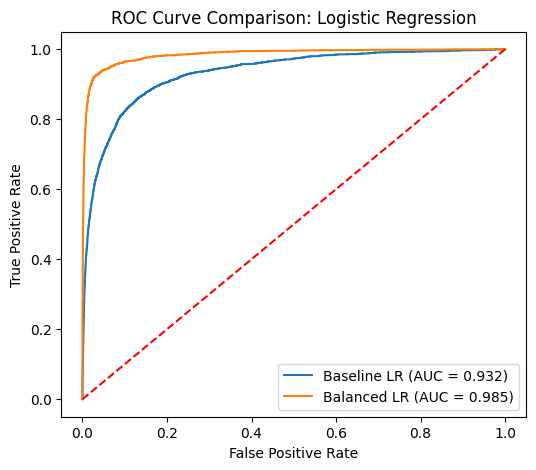

In [50]:
# ROC Curve karşılaştırması (Baseline vs Class_weight Logistic Regression)

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC eğrisi için gerekli değerleri hesaplıyoruz
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_lr_base)
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_lr_bal)

# AUC skorlarını hesaplıyoruz
auc_base = roc_auc_score(y_test, y_prob_lr_base)
auc_bal = roc_auc_score(y_test, y_prob_lr_bal)

# Grafiği çiziyoruz
plt.figure(figsize=(6,5))

plt.plot(fpr_base, tpr_base, label=f"Baseline LR (AUC = {auc_base:.3f})")
plt.plot(fpr_bal, tpr_bal, label=f"Balanced LR (AUC = {auc_bal:.3f})")

# Referans çizgisi (rastgele model)
plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Logistic Regression")

plt.legend()
plt.show()

Class imbalance problemi nedeniyle baseline Logistic Regression modeli fraud işlemleri yakalamakta yetersiz kalmıştır (recall = 0.25). Class_weight parametresi eklendikten sonra modelin fraud sınıfını yakalama başarısı önemli ölçüde artmış (recall = 0.93) ve ROC-AUC skoru 0.93’den 0.98’e yükselmiştir. Bu sonuçlar sınıf dengesizliği probleminin ağırlıklandırma yöntemi ile etkili şekilde azaltılabildiğini göstermektedir.

XGBOOST

XGBOOST Baseline- Threshold = 0.5 

In [52]:
# XGBoost baseline modeli

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Model oluşturuyoruz
xgb_baseline = XGBClassifier(
    n_estimators=100,      # ağaç sayısı
    max_depth=6,           # ağaç derinliği
    learning_rate=0.1,     # öğrenme hızı
    random_state=42,
    eval_metric="logloss"
)

# Modeli eğitiyoruz
xgb_baseline.fit(X_train, y_train)

# Tahmin alıyoruz
y_pred_xgb_base = xgb_baseline.predict(X_test)
y_prob_xgb_base = xgb_baseline.predict_proba(X_test)[:, 1]

# Sonuçları yazdırıyoruz
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb_base))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb_base))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb_base))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     53329
           1       0.93      0.88      0.90      2666

    accuracy                           0.99     55995
   macro avg       0.96      0.94      0.95     55995
weighted avg       0.99      0.99      0.99     55995

Confusion Matrix:

[[53159   170]
 [  331  2335]]
ROC-AUC Score: 0.9959752098387626


XGBoost baseline modeli yüksek doğruluk ve ROC-AUC skoru elde etmiştir. Model fraud işlemleri %88 recall ile yakalayabilmiş ve %93 precision değeri ile yanlış alarm oranını düşük tutmuştur. ROC-AUC skorunun 0.995 olması modelin fraud ve normal işlemleri ayırt etme gücünün oldukça yüksek olduğunu göstermektedir.

XGBOOST Baseline- Threshold = 0.4

In [53]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Model oluşturuyoruz
xgb_baseline = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Modeli eğitiyoruz
xgb_baseline.fit(X_train, y_train)

# 🎯 Threshold belirle
threshold = 0.4

# Probability al
y_prob_xgb_base = xgb_baseline.predict_proba(X_test)[:, 1]

# ❗ Threshold uygula
y_pred_xgb_base = (y_prob_xgb_base >= threshold).astype(int)

# Sonuçları yazdırıyoruz
print(f"Threshold: {threshold}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb_base))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb_base))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb_base))

Threshold: 0.4

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     53329
           1       0.91      0.90      0.90      2666

    accuracy                           0.99     55995
   macro avg       0.95      0.95      0.95     55995
weighted avg       0.99      0.99      0.99     55995

Confusion Matrix:

[[53089   240]
 [  270  2396]]
ROC-AUC Score: 0.9959752098387626


Decision threshold değeri 0.5 yerine 0.4 olarak ayarlandığında modelin fraud işlemleri yakalama oranı (recall) %88’den %90’a yükselmiştir. Bu durum modelin daha fazla fraud işlemi tespit etmesini sağlamış, ancak küçük bir precision düşüşüne neden olmuştur. Fraud detection problemlerinde recall değerinin yüksek olması kritik olduğundan threshold optimizasyonu model performansını iyileştirmiştir.

Threshold değerini 0.4’e düşürerek modelin fraud yakalama oranını artırdık ve recall değerini yükselttik. ROC-AUC skorunun 0.995 olması modelin oldukça güçlü bir ayırt ediciliğe sahip olduğunu gösteriyor.

XGBoost + scale_pos_weight

In [54]:
# XGBoost için class imbalance oranını hesaplıyoruz
# negatif sınıf / pozitif sınıf

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 19.99915619726233


XGboost + scale_weight- Threshold = 0.5

In [55]:
# XGBoost modeli (scale_pos_weight ile)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb_weighted = XGBClassifier(
    n_estimators=100,       # ağaç sayısı
    max_depth=6,            # ağaç derinliği
    learning_rate=0.1,      # öğrenme hızı
    scale_pos_weight=scale_pos_weight,   # fraud sınıfına daha fazla ağırlık
    random_state=42,
    eval_metric="logloss"
)

# Modeli eğitiyoruz
xgb_weighted.fit(X_train, y_train)

# Tahmin alıyoruz
y_pred_xgb_weighted = xgb_weighted.predict(X_test)
y_prob_xgb_weighted = xgb_weighted.predict_proba(X_test)[:, 1]

# Sonuçları yazdırıyoruz
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb_weighted))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb_weighted))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb_weighted))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     53329
           1       0.69      0.96      0.80      2666

    accuracy                           0.98     55995
   macro avg       0.84      0.97      0.89     55995
weighted avg       0.98      0.98      0.98     55995

Confusion Matrix:

[[52160  1169]
 [  100  2566]]
ROC-AUC Score: 0.996262120106336


Scale_pos_weight parametresi kullanılarak sınıf dengesizliği giderildiğinde modelin fraud işlemleri yakalama oranı (recall) %96’ya yükselmiştir. Bu durum modelin gerçek fraud vakalarını kaçırma riskini önemli ölçüde azaltmıştır. Precision değerinde küçük bir düşüş görülse de fraud detection problemlerinde recall değerinin yüksek olması kritik bir avantaj sağlamaktadır.

XGboost + scale_weight- Threshold = 0.7

In [56]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb_weighted = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Modeli eğit
xgb_weighted.fit(X_train, y_train)

# 🎯 Threshold belirle
threshold = 0.7

# Probability al
y_prob_xgb_weighted = xgb_weighted.predict_proba(X_test)[:, 1]

# ❗ Threshold uygula
y_pred_xgb_weighted = (y_prob_xgb_weighted >= threshold).astype(int)

# Sonuçlar
print(f"Threshold: {threshold}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb_weighted))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb_weighted))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb_weighted))

Threshold: 0.7

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     53329
           1       0.79      0.94      0.86      2666

    accuracy                           0.99     55995
   macro avg       0.89      0.97      0.93     55995
weighted avg       0.99      0.99      0.99     55995

Confusion Matrix:

[[52672   657]
 [  153  2513]]
ROC-AUC Score: 0.996262120106336


Decision threshold değeri 0.7 olarak ayarlandığında modelin precision değeri artmış ve yanlış alarm sayısı azaltılmıştır. Buna karşılık recall değeri küçük bir miktar düşmüştür. Bu durum modelin daha temkinli fraud tahmini yaptığını göstermektedir.

Scale_pos_weight parametresi kullanılarak model fraud sınıfına daha fazla ağırlık vermiş ve fraud işlemleri yakalama oranı önemli ölçüde artırılmıştır. Bu yaklaşım sınıf dengesizliği bulunan veri setlerinde model performansını iyileştirmek için etkili bir yöntemdir.

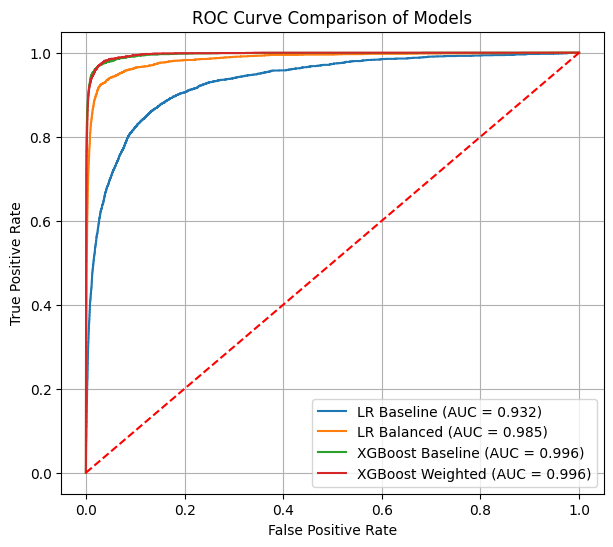

In [57]:
# ROC Curve karşılaştırması (tüm modeller)

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# Logistic Regression baseline
fpr_lr_base, tpr_lr_base, _ = roc_curve(y_test, y_prob_lr_base)
auc_lr_base = roc_auc_score(y_test, y_prob_lr_base)
plt.plot(fpr_lr_base, tpr_lr_base, label=f"LR Baseline (AUC = {auc_lr_base:.3f})")

# Logistic Regression + class_weight
fpr_lr_bal, tpr_lr_bal, _ = roc_curve(y_test, y_prob_lr_bal)
auc_lr_bal = roc_auc_score(y_test, y_prob_lr_bal)
plt.plot(fpr_lr_bal, tpr_lr_bal, label=f"LR Balanced (AUC = {auc_lr_bal:.3f})")

# XGBoost baseline
fpr_xgb_base, tpr_xgb_base, _ = roc_curve(y_test, y_prob_xgb_base)
auc_xgb_base = roc_auc_score(y_test, y_prob_xgb_base)
plt.plot(fpr_xgb_base, tpr_xgb_base, label=f"XGBoost Baseline (AUC = {auc_xgb_base:.3f})")

# XGBoost + scale_pos_weight
fpr_xgb_weighted, tpr_xgb_weighted, _ = roc_curve(y_test, y_prob_xgb_weighted)
auc_xgb_weighted = roc_auc_score(y_test, y_prob_xgb_weighted)
plt.plot(fpr_xgb_weighted, tpr_xgb_weighted, label=f"XGBoost Weighted (AUC = {auc_xgb_weighted:.3f})")

# Rastgele model referans çizgisi
plt.plot([0,1], [0,1], "r--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.grid(True)

plt.show()

<Figure size 1000x700 with 0 Axes>

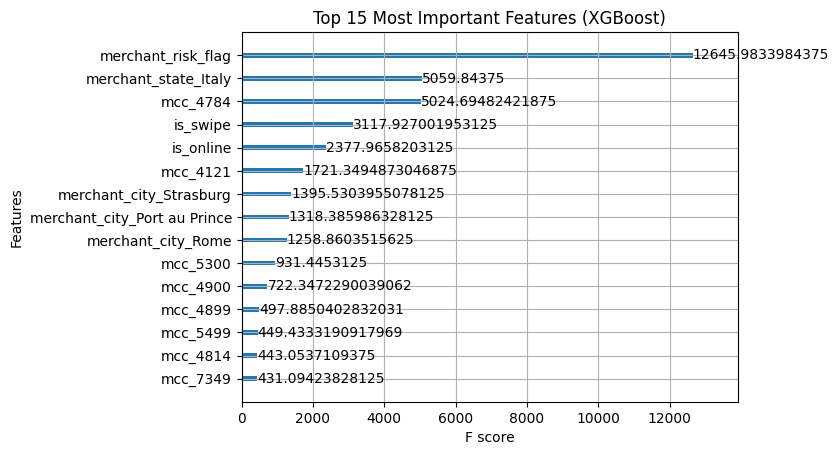

In [58]:
# XGBoost Feature Importance grafiği

from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

# Weighted XGBoost modelini kullanıyoruz (en iyi model)
plot_importance(
    xgb_weighted,
    max_num_features=15,   # en önemli 15 feature
    importance_type="gain" # model kararına katkı gücü
)

plt.title("Top 15 Most Important Features (XGBoost)")
plt.show()

Feature importance grafiği incelendiğinde modelin özellikle merchant_risk_flag değişkenine yüksek önem verdiği görülmektedir. Bunun yanında işlem yapılan ülke bilgisi, MCC kodları ve işlem tipi (online veya swipe) gibi değişkenlerin de fraud tahmininde belirleyici rol oynadığı anlaşılmaktadır.

Bu sonuçlar modelin hem merchant risk seviyesi hem de işlem davranışı ve lokasyon bilgilerini birlikte değerlendirerek karar verdiğini göstermektedir.

In [59]:
import joblib

joblib.dump(xgb_weighted, "../models/fraud_model_final_merve.joblib")

['../models/fraud_model_final_merve.joblib']